In [8]:
!pip install transformers datasets accelerate -q

In [9]:
!pip install --upgrade datasets huggingface_hub accelerate -q

In [10]:
# HuggingFace Transformers for modeling
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments

# PyTorch for deep learning framework
import torch
from torch.utils.data import Dataset

# Scikit-learn for model evaluation and data splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# NumPy and Pandas for data manipulation
import numpy as np
import pandas as pd

# Matplotlib for data visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("All libraries loaded successfully")


All libraries loaded successfully


In [11]:
# ==========================================
# Task 2: Load and Preprocess the Data
# ==========================================
from datasets import load_dataset

# 1. Load the dataset using HuggingFace datasets library
# We use a try-except block to first attempt loading the Webis dataset,
# and fallback to MRPC if it fails, as specified.
try:
    print("\nAttempting to load 'webis/sts-companion' dataset...")
    dataset = load_dataset("webis/sts-companion", split="train")
    print("Successfully loaded 'webis/sts-companion'")
except Exception as e:
    print(f"Could not load 'webis/sts-companion'. Falling back to 'glue', 'mrpc'...")
    dataset = load_dataset("glue", "mrpc", split="train")
    print("Successfully loaded 'glue' 'mrpc' dataset.")

# 2. Convert the dataset to a pandas DataFrame for easier exploration
df = pd.DataFrame(dataset)

print("\n--- Dataset Exploration ---")
# Print the first 5 rows
print("First 5 rows:")
print(df.head())

# Print the shape (number of rows and columns)
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Print the column names
print(f"\nColumn names: {df.columns.tolist()}")

# 3. Rename columns if needed to ensure we have standard names
# "sentence1" — first sentence, "sentence2" — second sentence, "label" — 0 or 1
rename_map = {}
if 'text1' in df.columns:
    rename_map['text1'] = 'sentence1'
if 'text2' in df.columns:
    rename_map['text2'] = 'sentence2'
if rename_map:
    df.rename(columns=rename_map, inplace=True)

# Value counts of the label column (how many paraphrases vs non-paraphrases)
print("\nLabel distribution (1 = paraphrase, 0 = non-paraphrase):")
print(df['label'].value_counts())

# 4. Drop any rows where sentence1 or sentence2 is null or empty
# First, replace empty strings with NaN so dropna() can catch them
df['sentence1'] = df['sentence1'].replace(r'^\s*$', np.nan, regex=True)
df['sentence2'] = df['sentence2'].replace(r'^\s*$', np.nan, regex=True)
initial_rows = len(df)
df.dropna(subset=['sentence1', 'sentence2'], inplace=True)
print(f"\nDropped {initial_rows - len(df)} rows with missing sentences.")

# 5. Print a final summary
num_paraphrases = (df['label'] == 1).sum()
num_non_paraphrases = (df['label'] == 0).sum()

print(f"\nDataset loaded: {len(df)} rows, {num_paraphrases} paraphrases, {num_non_paraphrases} non-paraphrases")



Attempting to load 'webis/sts-companion' dataset...
Could not load 'webis/sts-companion'. Falling back to 'SetFit/mrpc'...


README.md:   0%|          | 0.00/316 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/127k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/533k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

Successfully loaded 'SetFit/mrpc' dataset.

--- Dataset Exploration ---
First 5 rows:
                                               text1  \
0  Amrozi accused his brother , whom he called " ...   
1  Yucaipa owned Dominick 's before selling the c...   
2  They had published an advertisement on the Int...   
3  Around 0335 GMT , Tab shares were up 19 cents ...   
4  The stock rose $ 2.11 , or about 11 percent , ...   

                                               text2  label  idx  \
0  Referring to him as only " the witness " , Amr...      1    0   
1  Yucaipa bought Dominick 's in 1995 for $ 693 m...      0    1   
2  On June 10 , the ship 's owners had published ...      1    2   
3  Tab shares jumped 20 cents , or 4.6 % , to set...      0    3   
4  PG & E Corp. shares jumped $ 1.63 or 8 percent...      1    4   

       label_text  
0      equivalent  
1  not equivalent  
2      equivalent  
3  not equivalent  
4      equivalent  

Dataset shape: 3668 rows, 5 columns

Column nam

In [12]:
# ==========================================
# Task 3: Split the Dataset
# ==========================================

# 1. Extract the text data and labels from the DataFrame into lists
sentences1 = df['sentence1'].tolist()
sentences2 = df['sentence2'].tolist()
labels = df['label'].astype(int).tolist()

# WHY THREE SPLITS?
# 1. Train set: Used by the model to learn the patterns and update its weights.
# 2. Validation (Val) set: Used during training to monitor performance on unseen data,
#    prevent overfitting, and help tune hyperparameters.
# 3. Test set: Kept completely hidden until the very end for an honest, unbiased
#    evaluation of the final model's real-world performance.

# 2. First Split: Separate out 10% of the overall data as the TEST set.
# We stratify on labels to ensure the same ratio of paraphrases to non-paraphrases is maintained.
temp_s1, test_s1, temp_s2, test_s2, temp_labels, test_labels = train_test_split(
    sentences1, sentences2, labels,
    test_size=0.1,
    random_state=42,
    stratify=labels
)

# 3. Second Split: Separate the remaining 90% (temp) into TRAIN (80%) and VALIDATION (10%).
# 10% is 1/9th (approx 11.11%) of the remaining 90%.
train_s1, val_s1, train_s2, val_s2, train_labels, val_labels = train_test_split(
    temp_s1, temp_s2, temp_labels,
    test_size=1/9, # 11.11% of 90% is 10% of total
    random_state=42,
    stratify=temp_labels
)

# 5. Print the sizes of all three splits
print("\n--- Dataset Splits ---")
print(f"Train: {len(train_labels)} samples | Validation: {len(val_labels)} samples | Test: {len(test_labels)} samples")

# 6. Print the label distribution in each split to confirm stratification worked
print("\nLabel Distribution:")
print(f"Train labels      — 0: {train_labels.count(0)}, 1: {train_labels.count(1)}")
print(f"Validation labels — 0: {val_labels.count(0)}, 1: {val_labels.count(1)}")
print(f"Test labels       — 0: {test_labels.count(0)}, 1: {test_labels.count(1)}")



--- Dataset Splits ---
Train: 2934 samples | Validation: 367 samples | Test: 367 samples

Label Distribution:
Train labels      — 0: 955, 1: 1979
Validation labels — 0: 120, 1: 247
Test labels       — 0: 119, 1: 248


In [13]:
# ==========================================
# Task 4: Tokenize Datasets
# ==========================================

# WHY TOKENIZE?
# 1. RoBERTa (like all neural networks) only understands numbers, not raw text strings.
# 2. Tokenization converts text into numerical IDs.
# 3. For sentence pairs, RoBERTa needs special tokens to know where the first sentence
#    ends and the second begins. Passing two lists together automatically adds the
#    <s> sent1 </s></s> sent2 </s> format required by the model.

# 1. Load the pre-trained RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# 2. Function to tokenize sentence pairs
def tokenize_pairs(sentences1, sentences2):
    return tokenizer(
        sentences1,
        sentences2,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

# 3. Call this function on all three splits
train_encodings = tokenize_pairs(train_s1, train_s2)
val_encodings = tokenize_pairs(val_s1, val_s2)
test_encodings = tokenize_pairs(test_s1, test_s2)

# 4. Print the shape to confirm it worked (should be num_samples x 128)
print("\n--- Tokenization ---")
print(f"Train encodings input_ids shape: {train_encodings['input_ids'].shape}")

# 5. Print one example before, during, and after tokenization
print("\nExample Tokenization (First pair in Train set):")
print(f"Original Sentence 1: {train_s1[0]}")
print(f"Original Sentence 2: {train_s2[0]}")

first_input_ids = train_encodings['input_ids'][0]
print(f"\nTokenized IDs: {first_input_ids}")

decoded_example = tokenizer.decode(first_input_ids)
print(f"\nDecoded back to text: {decoded_example}")


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


--- Tokenization ---
Train encodings input_ids shape: torch.Size([2934, 128])

Example Tokenization (First pair in Train set):
Original Sentence 1: Had the creditors turned down the bailout plan , LG Group might have been forced to close down its credit card business .
Original Sentence 2: If the creditors turn down the bailout plan , LG Group may have to closedown its card business .

Tokenized IDs: tensor([    0, 32054,     5, 12089,  1224,   159,     5, 11103,   563,  2156,
         9528,   826,   429,    33,    57,  1654,     7,   593,   159,    63,
         1361,  1886,   265,   479,     2,     2,  1106,     5, 12089,  1004,
          159,     5, 11103,   563,  2156,  9528,   826,   189,    33,     7,
         1367,  3355,    63,  1886,   265,   479,     2,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,

In [14]:
# ==========================================
# Task 5: Generate Tensors (PyTorch Dataset)
# ==========================================

# WHY DO WE NEED THIS CLASS?
# The HuggingFace Trainer requires data to be in a very specific format.
# By wrapping our encodings and labels in a PyTorch Dataset class, the Trainer
# can automatically handle batching, shuffling, and moving data to the GPU.

class SimilarityDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # The Trainer expects a dictionary with 'input_ids', 'attention_mask', and 'labels'
        item = {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }
        return item

# 5. Instantiate all three datasets
train_dataset = SimilarityDataset(train_encodings, train_labels)
val_dataset = SimilarityDataset(val_encodings, val_labels)
test_dataset = SimilarityDataset(test_encodings, test_labels)

# 6. Test it works by printing properties
print("\n--- PyTorch Datasets ---")
print(f"Train Dataset length: {len(train_dataset)}")
print(f"Validation Dataset length: {len(val_dataset)}")
print(f"Test Dataset length: {len(test_dataset)}")

sample_item = train_dataset[0]
print(f"\nKeys in train_dataset[0]: {list(sample_item.keys())}")
print(f"Shape of input_ids in train_dataset[0]: {sample_item['input_ids'].shape}")



--- PyTorch Datasets ---
Train Dataset length: 2934
Validation Dataset length: 367
Test Dataset length: 367

Keys in train_dataset[0]: ['input_ids', 'attention_mask', 'labels']
Shape of input_ids in train_dataset[0]: torch.Size([128])


In [15]:
# ==========================================
# Task 6: Load Pretrained RoBERTa Model and Set Device
# Task 7: Prepare Training Arguments and Create Trainer Object
# ==========================================

# 1. Detect device automatically
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# 2. Load the pretrained RoBERTa model for Sequence Classification
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2
)
model.to(device)

# 3. Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params / 1_000_000:.1f}M")
print(f"Trainable parameters: {trainable_params / 1_000_000:.1f}M")

# 4. Write a compute_metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

# WHY THESE HYPERPARAMETERS?
# - learning_rate (2e-5): Small learning rates like 2e-5, 3e-5, or 5e-5 are standard
#   for fine-tuning Transformers because the model is already pre-trained; we just
#   want to gently nudge it towards our specific task without destroying its general knowledge.
# - warmup_steps (100): Gradually increases the learning rate from 0 to the target (2e-5)
#   over 100 steps to prevent unstable training at the very beginning.
# - weight_decay (0.01): Adds a small penalty to the weights to prevent the model from
#   becoming too complex and overfitting the training data.

# 5. Create TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch', # eval_strategy replaces evaluation_strategy in recent transformers
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy'
)

# 6. Create the Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\nModel and Trainer ready. Starting training...")



Using device: cuda


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Total parameters: 124.6M
Trainable parameters: 124.6M

Model and Trainer ready. Starting training...



--- Training Started ---


Epoch,Training Loss,Validation Loss,Accuracy
1,0.520931,0.397576,0.850136
2,0.317207,0.337313,0.855586
3,0.235854,0.455729,0.869210


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training Complete ---
Total training time: 4.15 minutes
Final training loss: 0.3870
Samples per second: 35.37


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model and tokenizer saved to ./roberta-similarity-model
Saved training history plot to 'training_history.png'.


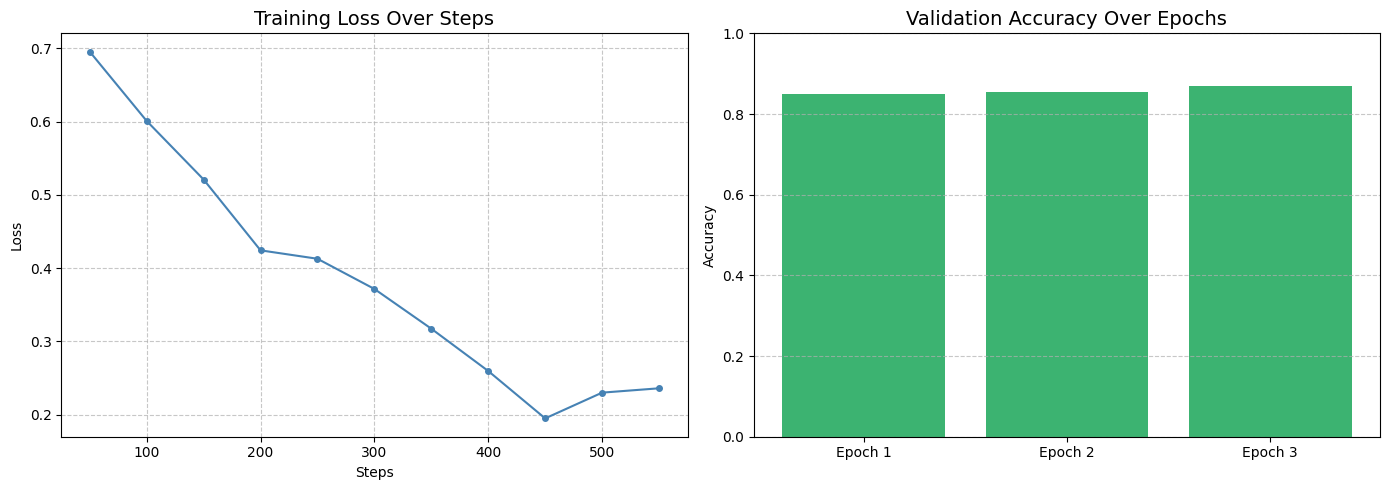


--- Validation Metrics Summary ---
 epoch  eval_loss  eval_accuracy  eval_runtime  eval_samples_per_second
   1.0   0.397576       0.850136        2.1819                  168.205
   2.0   0.337313       0.855586        2.2116                  165.941
   3.0   0.455729       0.869210        2.2200                  165.314


In [16]:
# ==========================================
# Task 8: Train the Model
# ==========================================

# WHAT IS FINE-TUNING?
# We are NOT training a model from scratch. RoBERTa has already been pre-trained on
# massive amounts of text and already understands the English language.
# Fine-tuning means we take this pre-trained intelligence and gently adjust its weights
# so it specializes in our specific task (detecting sentence similarity/paraphrases).

# 1. Start training
print("\n--- Training Started ---")
train_result = trainer.train()

# 2. Print completion metrics
metrics = train_result.metrics
train_time_mins = metrics["train_runtime"] / 60
print(f"\n--- Training Complete ---")
print(f"Total training time: {train_time_mins:.2f} minutes")
print(f"Final training loss: {metrics['train_loss']:.4f}")
print(f"Samples per second: {metrics['train_samples_per_second']:.2f}")

# 3. Save the trained model and tokenizer
model_dir = './roberta-similarity-model'
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)
print(f"\nModel and tokenizer saved to {model_dir}")

# 4. Extract training logs and plot history
log_history = trainer.state.log_history

# Separate out training loss and validation accuracy
train_steps = []
train_loss = []
val_epochs = []
val_accuracy = []

for log in log_history:
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
    if "eval_accuracy" in log and "epoch" in log:
        val_epochs.append(log["epoch"])
        val_accuracy.append(log["eval_accuracy"])

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training loss over steps (line chart)
ax1.plot(train_steps, train_loss, color='steelblue', marker='o', markersize=4)
ax1.set_title("Training Loss Over Steps", fontsize=14)
ax1.set_xlabel("Steps")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle='--', alpha=0.7)

# Right: Validation accuracy over epochs (bar chart)
epochs_str = [f"Epoch {int(e)}" for e in val_epochs]
ax2.bar(epochs_str, val_accuracy, color='mediumseagreen')
ax2.set_title("Validation Accuracy Over Epochs", fontsize=14)
ax2.set_ylabel("Accuracy")
ax2.set_ylim([0, 1.0]) # Accuracy is between 0 and 1
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('training_history.png')
print("Saved training history plot to 'training_history.png'.")
plt.show()

# 5. Print a summary table of metrics after each epoch
print("\n--- Validation Metrics Summary ---")
# Filter logs to just those that contain eval_accuracy
eval_logs = [log for log in log_history if "eval_accuracy" in log]
if eval_logs:
    df_evals = pd.DataFrame(eval_logs)
    # Select only the relevant columns for a clean summary table
    cols_to_show = ['epoch', 'eval_loss', 'eval_accuracy', 'eval_runtime', 'eval_samples_per_second']
    # Ensure columns exist before filtering
    cols_present = [c for c in cols_to_show if c in df_evals.columns]
    print(df_evals[cols_present].to_string(index=False))


In [17]:
# ==========================================
# Task 9: Test the Model and Calculate Accuracy
# ==========================================

# METRICS EXPLAINED:
# - Accuracy: The percentage of total predictions that were correct. However, if
#   90% of data is 'Not Paraphrase', a model that always guesses 'Not Paraphrase'
#   gets 90% accuracy but is actually useless! That's why we need other metrics:
# - Precision: Out of all the times the model *claimed* it was a paraphrase,
#   how many actually were? (Avoids False Positives).
# - Recall: Out of all the *actual* paraphrases in reality, how many did the
#   model successfully find? (Avoids False Negatives).
# - F1 Score: The harmonic mean of Precision and Recall. It's a balanced grade
#   that punishes extreme scores (e.g., high precision but terrible recall).

print("\n--- Evaluating on Test Set ---")
# 1. Run predictions on the unseen Test set
predictions = trainer.predict(test_dataset)
pred_logits = predictions.predictions
pred_labels = np.argmax(pred_logits, axis=1)
true_labels = predictions.label_ids

# 2. Calculate and print Accuracy and Classification Report
acc = accuracy_score(true_labels, pred_labels)
print(f"Overall Test Accuracy: {acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=['Not Paraphrase', 'Paraphrase']))



--- Evaluating on Test Set ---


Overall Test Accuracy: 83.38%

Classification Report:
                precision    recall  f1-score   support

Not Paraphrase       0.71      0.82      0.76       119
    Paraphrase       0.90      0.84      0.87       248

      accuracy                           0.83       367
     macro avg       0.81      0.83      0.82       367
  weighted avg       0.84      0.83      0.84       367



Saved confusion matrix plot to 'confusion_matrix.png'.


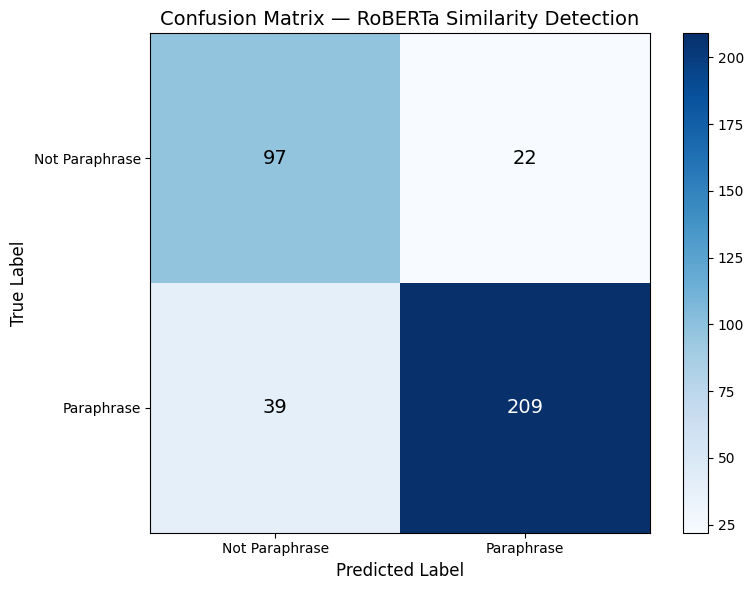


--- Confusion Matrix Breakdown ---
True Positives (correctly identified paraphrases): 209
True Negatives (correctly identified non-paraphrases): 97
False Positives (wrongly called paraphrase): 22
False Negatives (missed paraphrases): 39


In [18]:
# ==========================================
# Task 10: Compute and Display the Confusion Matrix
# ==========================================

# 3. Compute the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
tn, fp, fn, tp = cm.ravel()

# 4. Visualize it as a heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(cax)

classes = ['Not Paraphrase', 'Paraphrase']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Annotate each cell with its numerical count
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    ax.text(j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=14)

ax.set_title("Confusion Matrix — RoBERTa Similarity Detection", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png')
print("Saved confusion matrix plot to 'confusion_matrix.png'.")
plt.show()

# 5. Plain-English interpretation
print("\n--- Confusion Matrix Breakdown ---")
print(f"True Positives (correctly identified paraphrases): {tp}")
print(f"True Negatives (correctly identified non-paraphrases): {tn}")
print(f"False Positives (wrongly called paraphrase): {fp}")
print(f"False Negatives (missed paraphrases): {fn}")


In [19]:
# ==========================================
# BONUS: Live Prediction Function
# ==========================================

def predict_similarity(sentence1, sentence2):
    # Prepare the inputs
    inputs = tokenizer(
        sentence1,
        sentence2,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(device)

    # Run through the model without calculating gradients
    with torch.no_grad():
        outputs = model(**inputs)

    # Get logits and apply softmax to get probabilities
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1).squeeze()

    # Get the predicted class and its confidence
    pred_class = torch.argmax(probs).item()
    confidence = probs[pred_class].item() * 100

    label_str = "PARAPHRASE" if pred_class == 1 else "NOT PARAPHRASE"
    return f"{label_str} (Confidence: {confidence:.2f}%)"

print("\n--- BONUS: Testing Custom Pairs ---")

pair1 = ("The cat sat on the mat.", "A cat was resting on the rug.")
print(f"Pair 1: \n- {pair1[0]}\n- {pair1[1]}")
print(f"Result: {predict_similarity(*pair1)}\n")

pair2 = ("It is raining heavily.", "The stock market crashed today.")
print(f"Pair 2: \n- {pair2[0]}\n- {pair2[1]}")
print(f"Result: {predict_similarity(*pair2)}\n")

pair3 = ("She loves to read books.", "Reading is her favourite hobby.")
print(f"Pair 3: \n- {pair3[0]}\n- {pair3[1]}")
print(f"Result: {predict_similarity(*pair3)}\n")

print("Congratulations! The project is complete!")



--- BONUS: Testing Custom Pairs ---
Pair 1: 
- The cat sat on the mat.
- A cat was resting on the rug.
Result: PARAPHRASE (Confidence: 98.47%)

Pair 2: 
- It is raining heavily.
- The stock market crashed today.
Result: NOT PARAPHRASE (Confidence: 95.34%)

Pair 3: 
- She loves to read books.
- Reading is her favourite hobby.
Result: NOT PARAPHRASE (Confidence: 60.17%)

Congratulations! The project is complete!
